# Import all required Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [22]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    accuracy_score, precision_score, recall_score
)

# Models

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, BaggingClassifier, VotingClassifier,
    StackingClassifier
)
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


# Load & Explore Data

In [24]:
df = pd.read_csv('/kaggle/input/datasets/shashwatwork/cerebral-stroke-predictionimbalaced-dataset/dataset.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


In [26]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,36326.142350,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,21072.134879,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,1.000000,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,18038.500000,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,36351.500000,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,54514.250000,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


In [27]:
df.isnull().sum()

id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1462
smoking_status       13292
stroke                   0
dtype: int64

# Exploratory Data Analysis

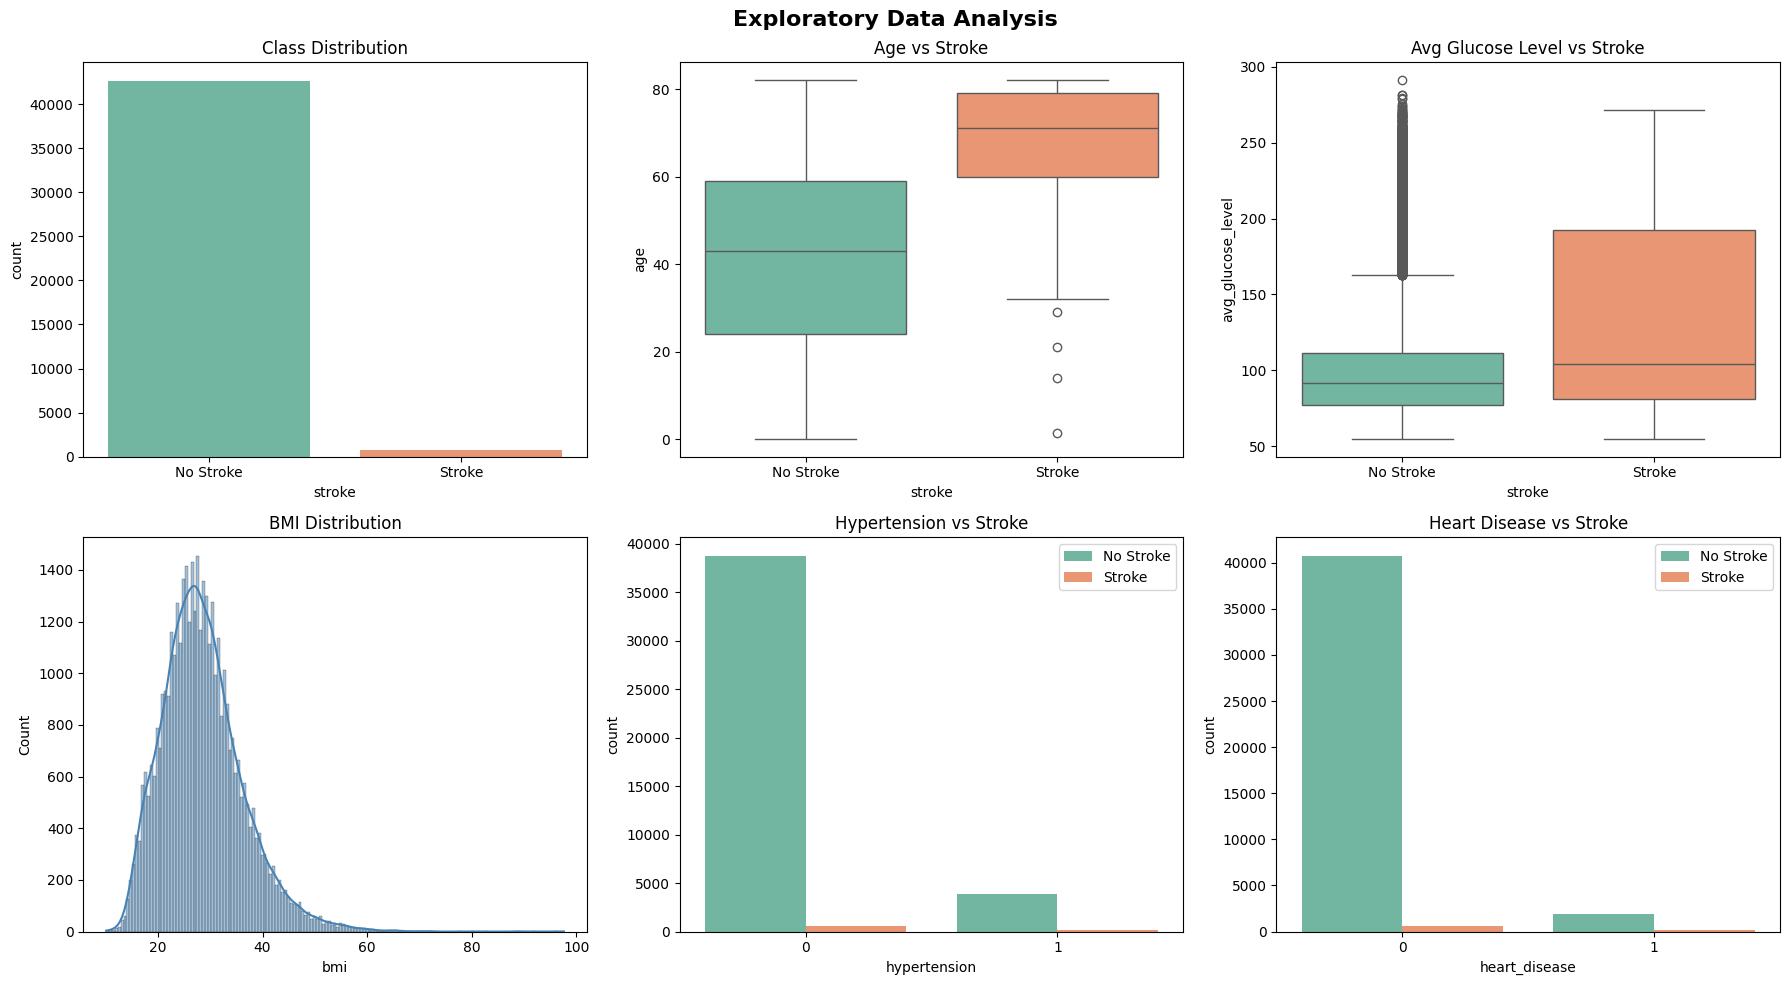

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Class Distribution
sns.countplot(x='stroke', data=df, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Class Distribution')
axes[0,0].set_xticklabels(['No Stroke', 'Stroke'])

# Age vs Stroke
sns.boxplot(x='stroke', y='age', data=df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Age vs Stroke')
axes[0,1].set_xticklabels(['No Stroke', 'Stroke'])

# Glucose vs Stroke
sns.boxplot(x='stroke', y='avg_glucose_level', data=df, ax=axes[0,2], palette='Set2')
axes[0,2].set_title('Avg Glucose Level vs Stroke')
axes[0,2].set_xticklabels(['No Stroke', 'Stroke'])

# BMI Distribution
sns.histplot(df['bmi'], kde=True, ax=axes[1,0], color='steelblue')
axes[1,0].set_title('BMI Distribution')

# Hypertension vs Stroke
sns.countplot(x='hypertension', hue='stroke', data=df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Hypertension vs Stroke')
axes[1,1].legend(['No Stroke', 'Stroke'])

# Heart Disease vs Stroke
sns.countplot(x='heart_disease', hue='stroke', data=df, ax=axes[1,2], palette='Set2')
axes[1,2].set_title('Heart Disease vs Stroke')
axes[1,2].legend(['No Stroke', 'Stroke'])

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Data Preprocessing

In [29]:
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

In [30]:
# Fill missing smoking_status with mode
df['smoking_status'].fillna(df['smoking_status'].mode()[0], inplace=True)

In [31]:
# Drop ID column (not useful for prediction)
df.drop('id', axis=1, inplace=True)

In [32]:
# One-hot encode categorical columns
df = pd.get_dummies(df, drop_first=True)

print('✅ Preprocessing complete')
print(f'Shape: {df.shape}')
df.head()

✅ Preprocessing complete
Shape: (43400, 16)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_never smoked,smoking_status_smokes
0,3.0,0,0,95.12,18.0,0,True,False,False,False,False,False,True,False,True,False
1,58.0,1,0,87.96,39.2,0,True,False,True,False,True,False,False,True,True,False
2,8.0,0,0,110.89,17.6,0,False,False,False,False,True,False,False,True,True,False
3,70.0,0,0,69.04,35.9,0,False,False,True,False,True,False,False,False,False,False
4,14.0,0,0,161.28,19.1,0,True,False,False,True,False,False,False,False,True,False


# Train-Test Split & SMOTE Balancing

In [33]:
X = df.drop('stroke', axis=1)
y = df['stroke']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Apply SMOTE only on training data

In [34]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

print(f'Training size (after SMOTE): {X_train_sc.shape}')
print(f'Test size: {X_test_sc.shape}')
print(f'Class distribution after SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}')

Training size (after SMOTE): (68188, 15)
Test size: (8680, 15)
Class distribution after SMOTE: {0: 34094, 1: 34094}


# Helper — Evaluation Function

In [35]:
results = {}  # Store metrics for comparison

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, plot_cm=True):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_proba) if y_proba is not None else None

    results[name] = {
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4) if auc else '-',
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(classification_report(y_te, y_pred))
    print(f'  ROC-AUC : {auc:.4f}' if auc else '')

    if plot_cm:
        cm = confusion_matrix(y_te, y_pred)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['No Stroke','Stroke'],
                    yticklabels=['No Stroke','Stroke'])
        plt.title(f'Confusion Matrix — {name}')
        plt.ylabel('Actual'); plt.xlabel('Predicted')
        plt.tight_layout()
        plt.savefig(f'cm_{name.replace(" ","_")}.png', dpi=120, bbox_inches='tight')
        plt.show()

    return model

print('✅ Evaluation function ready')

✅ Evaluation function ready


# Differnt Model Training

### 1. Baseline - Logistic Regression


  Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      8523
           1       0.06      0.48      0.10       157

    accuracy                           0.84      8680
   macro avg       0.52      0.66      0.51      8680
weighted avg       0.97      0.84      0.90      8680

  ROC-AUC : 0.7764


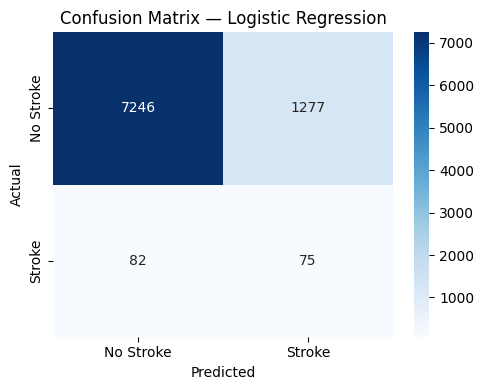

In [36]:
lr = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_sc, y_train_sm, X_test_sc, y_test
)

### 2. Decision Tree with Hyperparameter Tuning 

Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}

  Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      8523
           1       0.06      0.12      0.08       157

    accuracy                           0.95      8680
   macro avg       0.52      0.54      0.53      8680
weighted avg       0.97      0.95      0.96      8680

  ROC-AUC : 0.5419


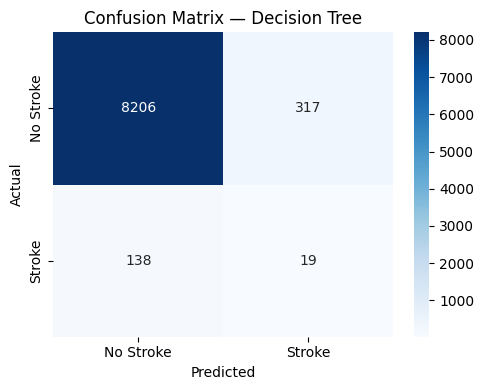

In [37]:
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1
)
dt_grid.fit(X_train_sc, y_train_sm)
print(f'Best params: {dt_grid.best_params_}')

dt = evaluate_model(
    'Decision Tree',
    dt_grid.best_estimator_,
    X_train_sc, y_train_sm, X_test_sc, y_test
)

### 3. Random Forest + Hyperparameter Tuning

Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}

  Random Forest
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      8523
           1       0.08      0.08      0.08       157

    accuracy                           0.97      8680
   macro avg       0.53      0.53      0.53      8680
weighted avg       0.97      0.97      0.97      8680

  ROC-AUC : 0.7809


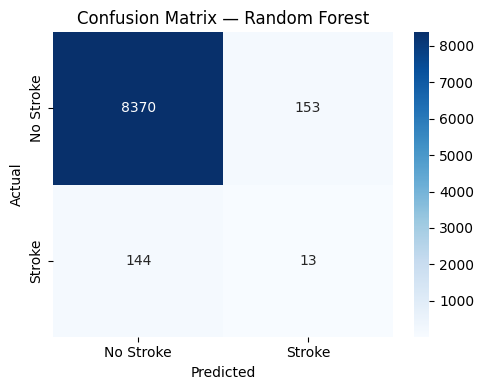

In [38]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1
)
rf_grid.fit(X_train_sc, y_train_sm)
print(f'Best params: {rf_grid.best_params_}')

rf = evaluate_model(
    'Random Forest',
    rf_grid.best_estimator_,
    X_train_sc, y_train_sm, X_test_sc, y_test
)

#### Random Forest - Featur Importance

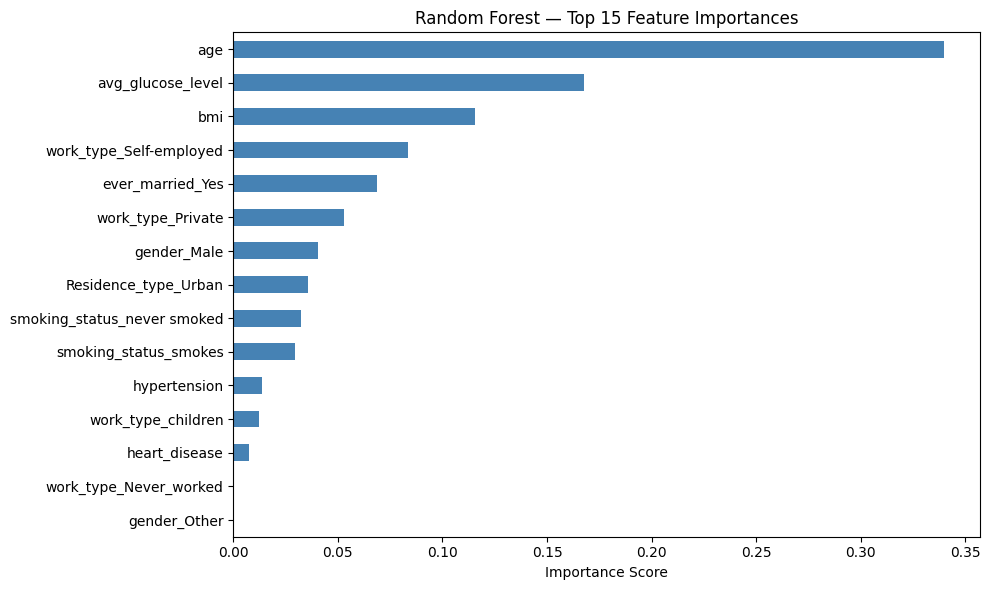

In [39]:
feat_imp = pd.Series(
    rf_grid.best_estimator_.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Random Forest — Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Gradient Boosting + Hyperparameter Tuning


In [ ]:
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1
)
gb_grid.fit(X_train_sc, y_train_sm)
print(f'Best params: {gb_grid.best_params_}')

gb = evaluate_model(
    'Gradient Boosting',
    gb_grid.best_estimator_,
    X_train_sc, y_train_sm, X_test_sc, y_test
)

### 5. XGBoost with Hyperparameter Tuning

In [ ]:
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False),
    xgb_params, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1
)
xgb_grid.fit(X_train_sc, y_train_sm)
print(f'Best params: {xgb_grid.best_params_}')

xgb = evaluate_model(
    'XGBoost',
    xgb_grid.best_estimator_,
    X_train_sc, y_train_sm, X_test_sc, y_test
)

### 6. Gradient Boosting + Hyperparameter Tuning

In [ ]:
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1
)
gb_grid.fit(X_train_sc, y_train_sm)
print(f'Best params: {gb_grid.best_params_}')

gb = evaluate_model(
    'Gradient Boosting',
    gb_grid.best_estimator_,
    X_train_sc, y_train_sm, X_test_sc, y_test
)

### 7. AdaBoost + Hyperparameter Tuning

In [ ]:
ada_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    ada_params, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1
)
ada_grid.fit(X_train_sc, y_train_sm)
print(f'Best params: {ada_grid.best_params_}')

ada = evaluate_model(
    'AdaBoost',
    ada_grid.best_estimator_,
    X_train_sc, y_train_sm, X_test_sc, y_test
)

### 8. SVM + Hyperparameter Tuning

In [ ]:
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_params, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1
)
svm_grid.fit(X_train_sc, y_train_sm)
print(f'Best params: {svm_grid.best_params_}')

svm = evaluate_model(
    'SVM',
    svm_grid.best_estimator_,
    X_train_sc, y_train_sm, X_test_sc, y_test
)

### 9. Bagging Classifier + Hyperparameter Tuning

In [ ]:
bag_params = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.6, 0.8, 1.0],
    'max_features': [0.6, 0.8, 1.0]
}

bag_grid = GridSearchCV(
    BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        random_state=42
    ),
    bag_params, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1
)
bag_grid.fit(X_train_sc, y_train_sm)
print(f'Best params: {bag_grid.best_params_}')

bag = evaluate_model(
    'Bagging Classifier',
    bag_grid.best_estimator_,
    X_train_sc, y_train_sm, X_test_sc, y_test
)

### 10. CatBoost + Hyperparameter Tuning

In [ ]:
cat_params = {
    'iterations': [100, 200],
    'depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2]
}

cat_grid = GridSearchCV(
    CatBoostClassifier(verbose=0, random_state=42),
    cat_params, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1
)
cat_grid.fit(X_train_sc, y_train_sm)
print(f'Best params: {cat_grid.best_params_}')

cat = evaluate_model(
    'CatBoost',
    cat_grid.best_estimator_,
    X_train_sc, y_train_sm, X_test_sc, y_test
)

### 11.Voting Classifier (Hard & Soft)

In [ ]:
# Soft Voting — uses predicted probabilities
voting_clf = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
        ('rf',  rf_grid.best_estimator_),
        ('xgb', xgb_grid.best_estimator_),
        ('gb',  gb_grid.best_estimator_),
        ('cat', cat_grid.best_estimator_)
    ],
    voting='soft'
)

voting = evaluate_model(
    'Voting Classifier',
    voting_clf,
    X_train_sc, y_train_sm, X_test_sc, y_test
)

### 12. Stacking Classifier

In [ ]:
# Base learners
base_learners = [
    ('dt',  dt_grid.best_estimator_),
    ('rf',  rf_grid.best_estimator_),
    ('xgb', xgb_grid.best_estimator_),
    ('gb',  gb_grid.best_estimator_),
    ('ada', ada_grid.best_estimator_)
]

# Meta learner
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=StratifiedKFold(5),
    passthrough=False,
    n_jobs=-1
)

stacking = evaluate_model(
    'Stacking Classifier',
    stacking_clf,
    X_train_sc, y_train_sm, X_test_sc, y_test
)

# Model Comparison — Summary Table

In [ ]:
summary = {
    k: {m: v for m, v in vals.items() if m not in ['model', 'y_pred', 'y_proba']}
    for k, vals in results.items()
}

df_summary = pd.DataFrame(summary).T.reset_index()
df_summary.columns = ['Model'] + list(df_summary.columns[1:])
df_summary = df_summary.sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_summary.index += 1
print(df_summary.to_string())

# Visual Comparison — Bar Chart

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
df_plot  = df_summary.set_index('Model')[metrics].astype(float)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
colors = plt.cm.tab10.colors

for ax, metric in zip(axes.flatten(), metrics):
    bars = ax.barh(df_plot.index, df_plot[metric], color=colors)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(0, 1.1)
    ax.invert_yaxis()
    for bar, val in zip(bars, df_plot[metric]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC Curves — All Models

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot([0,1],[0,1],'k--', label='Random Guess')

for name, res in results.items():
    if res['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        auc_score = res['ROC-AUC']
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score})")

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# F1-Score Radar / Spider Chart

In [ ]:
from matplotlib.patches import FancyArrowPatch

# Heatmap of all metrics
df_heat = df_summary.set_index('Model')[metrics].astype(float)

plt.figure(figsize=(10, 7))
sns.heatmap(df_heat, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Score'})
plt.title('Model Performance Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Best Model Identification & Final Report

In [ ]:
best_model_name = df_summary.iloc[0]['Model']
best_f1         = df_summary.iloc[0]['F1-Score']
best_auc        = df_summary.iloc[0]['ROC-AUC']

print('=' * 60)
print('  🏆  BEST MODEL SUMMARY')
print('=' * 60)
print(f'  Model     : {best_model_name}')
print(f'  F1-Score  : {best_f1}')
print(f'  ROC-AUC   : {best_auc}')
print('=' * 60)
print()
print('Full Leaderboard (sorted by F1-Score):')
print(df_summary[['Model','F1-Score','ROC-AUC','Accuracy','Recall']].to_string(index=False))